In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

In [2]:
df = pd.read_csv(
   "IMDB Dataset.csv"
)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
import re
import string

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Suthishna
[nltk_data]     kumar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
stop_words = set(stopwords.words("english"))


def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [6]:
df["label"] = df["sentiment"].map(
    {
        "negative": 0,
        "positive": 1
    }
)

print(df["label"].value_counts())

label
1    25000
0    25000
Name: count, dtype: int64


In [7]:
X = df["clean_review"]

y = df["label"]


X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42,
    stratify=y_temp
)


print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (34998,)
Validation: (7502,)
Testing: (7500,)


In [8]:
VOCAB_SIZE = 20000

MAX_LENGTH = 200


tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)


tokenizer.fit_on_texts(X_train)


X_train_seq = tokenizer.texts_to_sequences(
    X_train
)

X_val_seq = tokenizer.texts_to_sequences(
    X_val
)

X_test_seq = tokenizer.texts_to_sequences(
    X_test
)


print("Example Integer Sequence:")

print(X_train_seq[0])

Example Integer Sequence:
[37, 15, 62, 1, 25, 14, 17, 261, 212, 212, 192, 1145, 3588, 15, 15, 2, 16, 56, 57, 4, 1399, 511, 372, 31, 121, 4118, 13755, 1105, 1583, 2186, 143, 2391, 847, 3464, 56, 847, 1979, 780, 98, 535, 5207, 91, 1265, 4, 65, 911, 287, 1020, 1140, 2567, 25, 43, 89, 21, 14, 222, 480, 1070, 824, 10, 330, 7, 121, 38, 34, 16, 53]


In [9]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)


print("Training Shape:", X_train_pad.shape)

print("Validation Shape:", X_val_pad.shape)

print("Testing Shape:", X_test_pad.shape)

Training Shape: (34998, 200)
Validation Shape: (7502, 200)
Testing Shape: (7500, 200)


In [10]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)


X_train_tfidf = tfidf.fit_transform(
    X_train
)

X_val_tfidf = tfidf.transform(
    X_val
)

X_test_tfidf = tfidf.transform(
    X_test
)


print("Training Shape:", X_train_tfidf.shape)

print("Validation Shape:", X_val_tfidf.shape)

print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (34998, 20000)
Validation Shape: (7502, 20000)
Testing Shape: (7500, 20000)


In [11]:
tfidf_model = LogisticRegression(
    max_iter=1000
)


tfidf_model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(max_iter=1000)

In [12]:
tfidf_val_predictions = tfidf_model.predict(
    X_val_tfidf
)


tfidf_accuracy = accuracy_score(
    y_val,
    tfidf_val_predictions
)


print(
    "TF-IDF Validation Accuracy:",
    tfidf_accuracy
)

TF-IDF Validation Accuracy: 0.8961610237270061


In [13]:
embedding_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    GlobalAveragePooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        1,
        activation="sigmoid"
    )
])


embedding_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


embedding_model.summary()

C:\Users\Suthishna kumar\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = embedding_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=5,
    batch_size=64
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.6765 - loss: 0.5750 - val_accuracy: 0.8431 - val_loss: 0.3407
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.8994 - loss: 0.2537 - val_accuracy: 0.8807 - val_loss: 0.2889
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.9217 - loss: 0.2043 - val_accuracy: 0.8906 - val_loss: 0.2795
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9366 - loss: 0.1702 - val_accuracy: 0.8644 - val_loss: 0.3436
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.9474 - loss: 0.1460 - val_accuracy: 0.8823 - val_loss: 0.3248


In [15]:
embedding_val_loss, embedding_val_accuracy = (
    embedding_model.evaluate(
        X_val_pad,
        y_val
    )
)

print(
    "Embedding Validation Accuracy:",
    embedding_val_accuracy
)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8779 - loss: 0.3393
Embedding Validation Accuracy: 0.8822980523109436


In [16]:
for layer in embedding_model.layers:

    print(
        layer.name,
        "- Trainable:",
        layer.trainable
    )

embedding - Trainable: True
global_average_pooling1d - Trainable: True
dense - Trainable: True
dropout - Trainable: True
dense_1 - Trainable: True


In [18]:
#Compare TF-IDF and Trainable Embedding
comparison = pd.DataFrame({

    "Feature Representation": [
        "TF-IDF",
        "Tokenization + Integer Encoding + Trainable Embedding"
    ],

    "Validation Accuracy": [
        tfidf_accuracy,
        embedding_val_accuracy
    ]
})


comparison

,Feature Representation,Validation Accuracy
0,TF-IDF,0.896161
1,Tokenization + Integer Encoding + Trainable Em...,0.882298


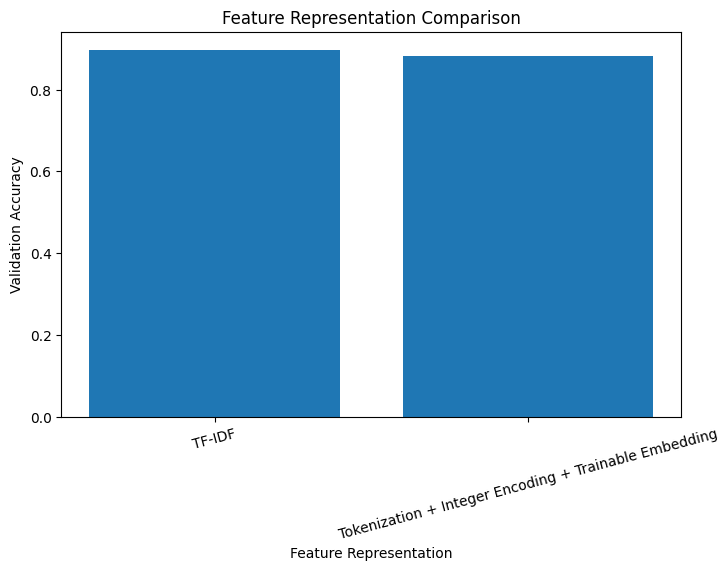

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Feature Representation"],
    comparison["Validation Accuracy"]
)

plt.title(
    "Feature Representation Comparison"
)

plt.xlabel(
    "Feature Representation"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.xticks(
    rotation=15
)

plt.show()

In [20]:
print("PHASE 3 COMPLETED")

print("\nFeature Representations Implemented:")

print(
    "1. Tokenization + Integer Encoding"
)

print(
    "2. TF-IDF"
)

print(
    "3. Word Embeddings"
)

print(
    "4. Trainable Embedding Layer"
)

print("\nTF-IDF Validation Accuracy:")
print(round(tfidf_accuracy, 4))

print("\nEmbedding Validation Accuracy:")
print(round(embedding_val_accuracy, 4))

PHASE 3 COMPLETED

Feature Representations Implemented:
1. Tokenization + Integer Encoding
2. TF-IDF
3. Word Embeddings
4. Trainable Embedding Layer

TF-IDF Validation Accuracy:
0.8962

Embedding Validation Accuracy:
0.8823
